# **Load Week 2 artifact**

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

artifact = joblib.load("week2_best_model.joblib")

model = artifact["model"]                # Week 2's best model, already trained
model_name = artifact["model_name"]
X_train = artifact["X_train"]
X_test = artifact["X_test"]
y_train = artifact["y_train"]
y_test = artifact["y_test"]
feature_names = artifact["feature_names"]

print(f"Loaded Week 2 best model: {model_name}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Loaded Week 2 best model: Random Forest
Train shape: (28032, 18), Test shape: (7008, 18)


# **Scaler + PCA**

In [ ]:
# Fit scaler and PCA on X_train only, then transform both train and test.
# Fitting on the full dataset would leak test-set variance/covariance
# structure into the components, this is the same leakage risk as fitting
# a scaler on the full data before a train/test split.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train.shape[1]
pca_full = PCA(n_components=n_features, random_state=42)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# **Scree plot**

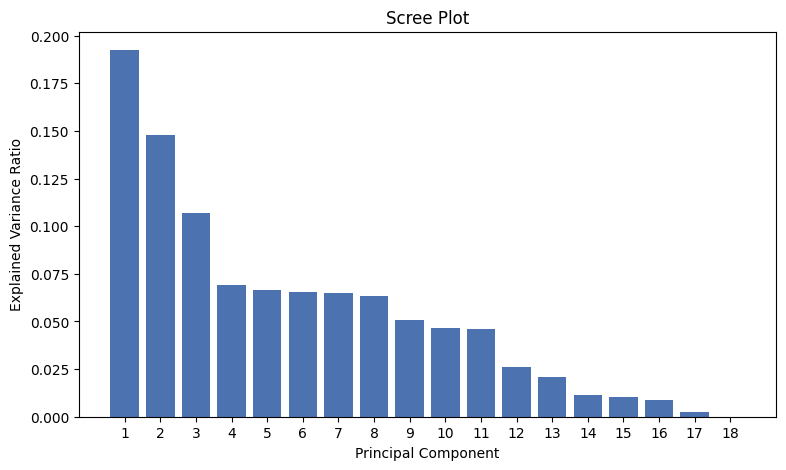

In [3]:
plt.figure(figsize=(9, 5))
plt.bar(range(1, n_features + 1), explained_var, color='#4C72B0')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, n_features + 1))
plt.show()

# **Cumulative variance curve + 95% threshold**

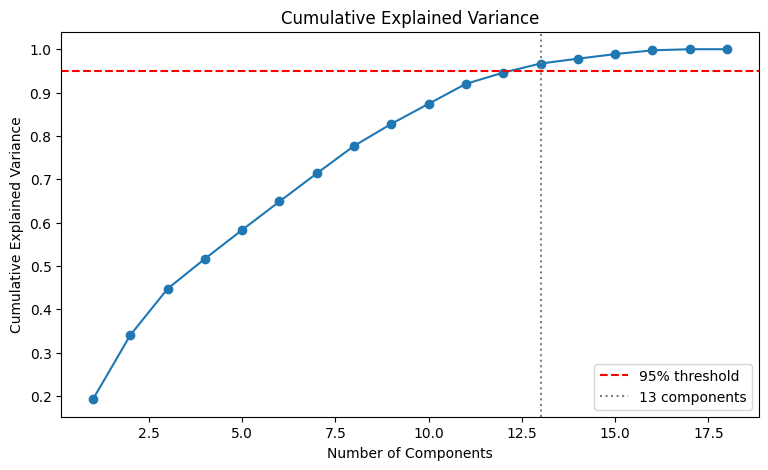

Components needed for 95% variance: 13


In [4]:
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

plt.figure(figsize=(9, 5))
plt.plot(range(1, n_features + 1), cumulative_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='gray', linestyle=':',
            label=f'{n_components_95} components')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()

print(f"Components needed for 95% variance: {n_components_95}")

# **Baseline: Week 2's model, unchanged**

In [ ]:
# Use the model exactly as loaded, no retraining, since it's already fit
# on X_train with all 18 raw features. This is the "original model" reference
# point for the comparison in requirement 8.
preds_baseline = model.predict(X_test)
rmse_baseline = np.sqrt(mean_squared_error(y_test, preds_baseline))
r2_baseline = r2_score(y_test, preds_baseline)
print(f"Baseline ({model_name}, {n_features} features): RMSE={rmse_baseline:.3f}, R2={r2_baseline:.4f}")

Baseline (Random Forest, 18 features): RMSE=0.931, R2=0.9992


# **Retrain with 3 PCA components**

In [6]:
pca_3 = PCA(n_components=3, random_state=42)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)

rf_pca3 = RandomForestRegressor(random_state=42)
rf_pca3.fit(X_train_pca3, y_train)
preds_pca3 = rf_pca3.predict(X_test_pca3)

rmse_pca3 = np.sqrt(mean_squared_error(y_test, preds_pca3))
r2_pca3 = r2_score(y_test, preds_pca3)
print(f"3-component PCA: RMSE={rmse_pca3:.3f}, R2={r2_pca3:.4f}, "
      f"variance captured={pca_3.explained_variance_ratio_.sum():.3f}")

3-component PCA: RMSE=11.228, R2=0.8892, variance captured=0.447


# **Retrain with 95%-variance component count**

In [7]:
pca_95 = PCA(n_components=n_components_95, random_state=42)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)

rf_pca95 = RandomForestRegressor(random_state=42)
rf_pca95.fit(X_train_pca95, y_train)
preds_pca95 = rf_pca95.predict(X_test_pca95)

rmse_pca95 = np.sqrt(mean_squared_error(y_test, preds_pca95))
r2_pca95 = r2_score(y_test, preds_pca95)
print(f"{n_components_95}-component PCA: RMSE={rmse_pca95:.3f}, R2={r2_pca95:.4f}")

13-component PCA: RMSE=7.630, R2=0.9488


# **Comparison table**

In [8]:
comparison = pd.DataFrame({
    "Model": [f"Original ({model_name}, {n_features} features)",
              "PCA - 3 components",
              f"PCA - {n_components_95} components (95% var)"],
    "RMSE": [rmse_baseline, rmse_pca3, rmse_pca95],
    "R2": [r2_baseline, r2_pca3, r2_pca95]
})
print(comparison.to_string(index=False))

                                Model      RMSE       R2
Original (Random Forest, 18 features)  0.930858 0.999238
                   PCA - 3 components 11.228329 0.889197
        PCA - 13 components (95% var)  7.630448 0.948829


# **Loading heatmap**

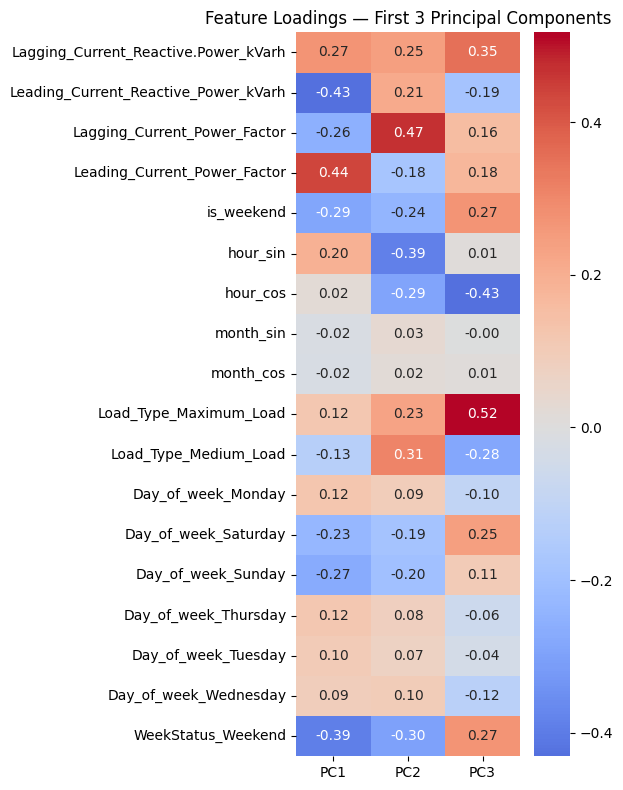

In [9]:
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    index=feature_names,
    columns=['PC1', 'PC2', 'PC3']
)

plt.figure(figsize=(6, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Loadings — First 3 Principal Components")
plt.tight_layout()
plt.show()

# **Save pipelines**

In [10]:
joblib.dump({"scaler": None, "pca": None, "model": model, "feature_names": feature_names},
            "week3_model_baseline.joblib")
joblib.dump({"scaler": scaler, "pca": pca_3, "model": rf_pca3, "feature_names": feature_names},
            "week3_model_pca3.joblib")
joblib.dump({"scaler": scaler, "pca": pca_95, "model": rf_pca95, "feature_names": feature_names},
            "week3_model_pca95.joblib")
print("Saved: week3_model_baseline.joblib, week3_model_pca3.joblib, week3_model_pca95.joblib")

Saved: week3_model_baseline.joblib, week3_model_pca3.joblib, week3_model_pca95.joblib


## Dimensionality Reduction Report

**Did accuracy drop significantly?**
Yes, substantially, in both PCA versions. The baseline Random Forest on all 18
raw features achieves RMSE 0.931 / R² 0.9992. Reducing to just 3 components
(which capture only 44.7% of total variance) pushes RMSE to 11.228, roughly
a 12x degradation. Even retaining 95% of variance requires 13 of the 18
components, and RMSE still degrades to 7.630 (~8x worse than baseline).
Variance and predictive relevance aren't the same thing here: the one-hot
day-of-week columns each carry independent variance that PCA can't compress
without discarding information the tree splits were actually using.

**How many features can safely be removed?**
Effectively none, if RMSE is the priority. This dataset only has 18 features
to begin with, and the baseline already achieves near-perfect accuracy on all
of them. PCA's compression (18 to 13 components for 95% variance) barely
reduces dimensionality while costing meaningful accuracy. A relevance-based
selection method would likely preserve far more accuracy per feature removed than variance-based
PCA does.

**Would you recommend PCA for a memory-constrained device?**
Not for this model and dataset. The accuracy cost is too high for an
energy-monitoring use case where prediction errors compound, and the memory
savings don't target the actual bottleneck: storing 18 floats instead of 3
or 13 is negligible on any device that can run a trained Random Forest at
all. The model itself (many trees, many nodes) is far larger than the input
vector. If memory were genuinely constrained, model compression (fewer or
shallower trees, or a lighter model class) would help more directly than
reducing input dimensionality.